# Results Notebook

This Notebook contains the code for generating all figures and tables in the paper, using raw results from the experimaestro workspace.

# Imports and Utils

In [ ]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from format import loss_names, backbone_names, DATASET_TO_ABB, aggregations

# Labeling
aggregations_paper = aggregations | {"OOD": aggregations["Lotte-S"] + ["robust04"]}
ignore_losses = ["infoNCE_norm_size=True"]
# use ACM style

FONT_SIZE = 14

# Set font for publication quality
# plt.rcParams['font.family'] = 'Times New Roman'
# 1. Configure Matplotlib for ACM Style
plt.rcParams.update(
    {
        "text.usetex": False,  # Set to True if you have LaTeX installed on your system
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
        "font.size": 10,  # Standard ACM body text size is ~9-10pt
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 12,
    }
)
plt.style.use("ggplot")


# default_workspace_path
# ws = get_workspace().path
# xps_root = ws / "experiments"

xps_root = Path("/Users/victor/code/experiments/JZ")


def get_last_xp(xp_id, force_date=None) -> str:
    dates = list((xps_root / xp_id).glob("*"))
    print(f"Found dates for {xp_id}: {[d.name for d in sorted(dates)]}")

    # parse and get most recent date
    if force_date is not None:
        forced_date_path = xps_root / xp_id / force_date
        if forced_date_path in dates:
            most_recent_date = forced_date_path
            print(f"Using forced date for {xp_id}: {most_recent_date.name}")
            return most_recent_date
        else:
            print(f"Forced date {force_date} not found for xp {xp_id}")

    dates = [d for d in dates if re.match(r"\d+_\d+", d.name)]

    if len(dates) == 0:
        print(f"No valid dates found for xp {xp_id}, returning dry-run")
        return xps_root / xp_id / "dry-run"

    most_recent_date = max(dates, key=lambda d: d.name)

    print(f"Most recent date for {xp_id}: {most_recent_date.name}")

    return most_recent_date


def get_results(xp_path) -> pd.DataFrame:
    path = xp_path / "results"
    csv_files = list(path.glob("results.csv"))

    if len(csv_files):
        return pd.read_csv(csv_files[0])
    else:
        raise ValueError(f"no csv files found in {path}")


def process_results(results) -> pd.DataFrame:
    labels1 = results.iloc[0]
    labels2 = results.iloc[1]
    labels = [
        f"{l1}{'_' + str(l2) if str(l2) != 'nan' else ''}"
        for l1, l2 in zip(labels1, labels2)
    ]
    labels[0] = "dataset"
    results.columns = labels
    results = results.iloc[2:]
    # Select columns containing 'mean' or 'var' (case-insensitive)
    cols_to_convert = results.filter(regex="(?i)mean|var").columns

    # Convert those columns to numeric, turning errors (like 'None' strings) into NaN
    results[cols_to_convert] = results[cols_to_convert].apply(
        pd.to_numeric, errors="coerce"
    )

    return results


def get_aggregated_stats(results, group_cols, metrics):
    # 3. Ensure numeric types
    all_cols = []
    for m in metrics:
        all_cols.extend([f"{m}_mean", f"{m}_var"])

    for col in all_cols:
        results[col] = pd.to_numeric(results[col], errors="coerce")

    # 4. Compute the Simple Average of Means and Variances
    #    We do NOT add the inter-dataset variance here.
    #    We act as if the datasets are fixed strata.
    aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

    # 5. Rename columns for clarity
    #    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
    rename_dict = {}
    for m in metrics:
        rename_dict[f"{m}_mean"] = f"{m}_Grand_Mean"
        rename_dict[f"{m}_var"] = f"{m}_Average_Var"

    aggregated_stats = aggregated_stats.rename(columns=rename_dict)

    return aggregated_stats
    # Add experiment label


def get_aggregated_df(df, datasets, name):
    """
    Returns a NEW DataFrame with aggregated means for specific datasets.
    Does not modify the original df.
    """
    # 1. Identify metric columns and metadata columns
    metric_cols = df.filter(regex="(?i)mean|var").columns.tolist()
    # Metadata columns are everything EXCEPT the metrics and the dataset name
    metadata_cols = [c for c in df.columns if c not in metric_cols and c != "dataset"]

    # 2. Filter rows for the specified datasets
    subset = df[df["dataset"].isin(datasets)].copy()
    subset[metric_cols] = subset[metric_cols].apply(pd.to_numeric, errors="coerce")

    # 3. Group by ALL metadata columns to preserve them
    # This keeps 'base', 'loss', 'scorer', 'arch', etc. intact
    new_df = subset.groupby(metadata_cols, as_index=False)[metric_cols].mean()

    # 4. Assign the new dataset aggregate name
    new_df["dataset"] = name

    # Reorder for readability: dataset first, then metadata, then metrics
    cols = ["dataset"] + metadata_cols + metric_cols
    return new_df[cols]


print(f"found xps in {xps_root}")
all_xps = list(xps_root.glob("*"))
for xp in sorted(all_xps):
    print(f"- {xp.name}")

/Users/victor/code/projects/cross-encoders/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


found xps in /Users/victor/code/experiments/JZ
- baseline_MiniLM_CE
- baseline_small_CE
- colbertNeg_base
- colbertNeg_infoNCE_precision
- colbertNeg_mini
- comparison_precision
- core_base
- core_base_deberta
- core_base_deberta_top100
- core_base_ettin
- core_base_ettin_1b
- core_base_ettin_scaling
- core_base_ettin_scaling_except_1b
- core_base_paper
- core_mini
- core_mini_debug
- cross_scorer_evaluation
- cross_scorer_evaluation_debug
- debug_CE_training
- debug_mice_training
- eval_masked_step0
- eval_scorer_debug
- eval_scorer_top100
- eval_scorer_top1000
- hyperparams_search_contrastive
- reproduction_RankDistiLLM
- train_mice_ettin_150m
- train_mice_ettin_17m
- train_mice_ettin_32m
- train_mice_ettin_68m
- train_mice_miniLM
- train_mice_miniLM_L4_abl_bounded
- train_mice_miniLM_L4_abl_bsize
- train_mice_miniLM_L8_abl_loss
- train_mice_miniLM_X+3
- train_mice_miniLM_X+3_inverted
- train_mice_miniLM_abl_clstodoc
- train_mice_miniLM_abl_clstodoc_reversed
- train_mice_miniLM_abl_v

# Loading Results

In [3]:
# Main table
import pandas as pd

xps = [
    "core_base_paper",
    "core_mini",
]


def get_tag(tagspath: str, regex: str) -> dict:
    match = re.search(regex, tagspath)
    if match:
        return match.group(1)
    return None


raw_dfs = []
for xp in xps:
    xp_path = xps_root / xp / "dry-run"
    print(f"using xp path {xp_path}")
    raw_dfs.append(process_results(get_results(xp_path)))

df = pd.concat(raw_dfs)


# Define regex patterns for tags
tags = {
    "base": r"base=(.*)_learner",
    "loss": r"\.loss=(.*)",
}

# Split "scorer" into separate columns using the regex patterns
for tag_name, pattern in tags.items():
    df[tag_name] = df["scorer"].apply(lambda x: get_tag(x, pattern))

datasets = list(df["dataset"].unique())
print(f" - {len(datasets)} unique datasets : {', '.join(datasets)}")
print(f" - Losses : {', '.join(list(df['loss'].unique()))}")
print(f" - Backbones : {', '.join(list(df['base'].unique()))}")
df.head()

using xp path /Users/victor/code/experiments/JZ/core_base_paper/dry-run
using xp path /Users/victor/code/experiments/JZ/core_mini/dry-run
 - 23 unique datasets : arguana, climate_fever, dbpedia, fever, fiqa, hotpotqa, lotte_lifestyle, lotte_recreation, lotte_science, lotte_technology, lotte_writing, msmarco_dev, nfcorpus, nq, quora, robust04, scidocs, scifact, touche, trec2019, trec2020, trec_covid, mean
 - Losses : ADR_MSE, bce, distillRankNET, hingeLoss, infoNCE_RankDistiLLM_norm_size=True, marginMSE, infoNCE_norm_size=True
 - Backbones : FacebookAI/roberta-base, bert-base-uncased, google/electra-base-discriminator, jhu-clsp/ettin-encoder-150m, microsoft/deberta-v3-base, jhu-clsp/ettin-encoder-17m, jhu-clsp/ettin-encoder-32m, jhu-clsp/ettin-encoder-68m, microsoft/MiniLM-L12-H384-uncased


,dataset,first_stage,scorer,validation,AP_mean,AP_var,RR@10_mean,RR@10_var,nDCG@10_mean,nDCG@10_var,base,loss
2,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=ADR_MSE,nano-beir,0.201600,0.000004,0.186233,0.000006,0.274100,0.000027,FacebookAI/roberta-base,ADR_MSE
3,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=bce,nano-beir,0.224433,0.000058,0.211167,0.000054,0.313000,0.000099,FacebookAI/roberta-base,bce
4,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=dist...,nano-beir,0.197500,0.000093,0.182267,0.000096,0.272900,0.000097,FacebookAI/roberta-base,distillRankNET
5,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=hing...,nano-beir,0.221600,0.000011,0.208000,0.000012,0.307267,0.000035,FacebookAI/roberta-base,hingeLoss
6,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=info...,nano-beir,0.224433,0.000097,0.210833,0.000110,0.312700,0.000242,FacebookAI/roberta-base,infoNCE_RankDistiLLM_norm_size=True


# Figure 1

In [42]:
import pandas as pd

# Create a list to store the new summary dataframes
summary_dfs = [df]

for name, datasets in aggregations_paper.items():
    agg_result = get_aggregated_df(df, datasets=datasets, name=name)
    summary_dfs.append(agg_result)

# Combine all aggregations into one single new table
final_summary_df = pd.concat(summary_dfs, ignore_index=True)

display(final_summary_df)
print(f" - Losses : {', '.join(list(final_summary_df['loss'].unique()))}")
print(f" - Datasets : {', '.join(list(final_summary_df['dataset'].unique()))}")

,dataset,first_stage,scorer,validation,AP_mean,AP_var,RR@10_mean,RR@10_var,nDCG@10_mean,nDCG@10_var,base,loss
0,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=ADR_MSE,nano-beir,0.201600,0.000004,0.186233,0.000006,0.274100,0.000027,FacebookAI/roberta-base,ADR_MSE
1,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=bce,nano-beir,0.224433,0.000058,0.211167,0.000054,0.313000,0.000099,FacebookAI/roberta-base,bce
2,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=dist...,nano-beir,0.197500,0.000093,0.182267,0.000096,0.272900,0.000097,FacebookAI/roberta-base,distillRankNET
3,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=hing...,nano-beir,0.221600,0.000011,0.208000,0.000012,0.307267,0.000035,FacebookAI/roberta-base,hingeLoss
4,arguana,naver/splade-v3-distilbert,base=FacebookAI/roberta-base_learner.loss=info...,nano-beir,0.224433,0.000097,0.210833,0.000110,0.312700,0.000242,FacebookAI/roberta-base,infoNCE_RankDistiLLM_norm_size=True
...,...,...,...,...,...,...,...,...,...,...,...,...
1619,OOD,naver/splade-v3-distilbert,base=microsoft/deberta-v3-base_learner.loss=bce,nano-beir,0.399928,0.000016,0.575622,0.000214,0.482022,0.000084,microsoft/deberta-v3-base,bce
1620,OOD,naver/splade-v3-distilbert,base=microsoft/deberta-v3-base_learner.loss=di...,nano-beir,0.425833,0.000007,0.625689,0.000061,0.519439,0.000024,microsoft/deberta-v3-base,distillRankNET
1621,OOD,naver/splade-v3-distilbert,base=microsoft/deberta-v3-base_learner.loss=hi...,nano-beir,0.416750,0.000028,0.609983,0.000070,0.507467,0.000041,microsoft/deberta-v3-base,hingeLoss
1622,OOD,naver/splade-v3-distilbert,base=microsoft/deberta-v3-base_learner.loss=in...,nano-beir,0.423306,0.000084,0.616289,0.000137,0.513778,0.000093,microsoft/deberta-v3-base,infoNCE_RankDistiLLM_norm_size=True


 - Losses : ADR_MSE, bce, distillRankNET, hingeLoss, infoNCE_RankDistiLLM_norm_size=True, marginMSE, infoNCE_norm_size=True
 - Datasets : arguana, climate_fever, dbpedia, fever, fiqa, hotpotqa, lotte_lifestyle, lotte_recreation, lotte_science, lotte_technology, lotte_writing, msmarco_dev, nfcorpus, nq, quora, robust04, scidocs, scifact, touche, trec2019, trec2020, trec_covid, mean, In Domain, minified, BEIR13, Lotte-S, OOD


## Merging V2 results dataframes

In [43]:
### Discard v1 results for deberta 
final_summary_df = final_summary_df[
    final_summary_df["base"] != "microsoft/deberta-v3-base"
    ]

In [44]:
# Main table

xps = [
    "core_base_deberta",
]

def process_results_v2(results) -> pd.DataFrame:
    labels1 = results.iloc[0]
    labels2 = results.iloc[1]
    labels = [
        f"{l1}{'_' + str(l2) if str(l2) != 'nan' else ''}"
        for l1, l2 in zip(labels1, labels2)
    ]
    labels[0] = "dataset"
    results.columns = labels
    results = results.iloc[2:]
    # Select columns containing 'mean' or 'var' (case-insensitive)
    cols_to_convert = results.filter(regex="(?i)mean|var").columns

    # Convert those columns to numeric, turning errors (like 'None' strings) into NaN
    results[cols_to_convert] = results[cols_to_convert].apply(
        pd.to_numeric, errors="coerce"
    )

    return results

raw_dfs = []
for xp in xps:
    xp_path = xps_root / xp / "dry-run"
    xp_path = get_last_xp(xps_root / xp)
    xp_path = xps_root / xp / "20260418_142408"
    print(f"Using xp path: {xp_path}")
    # raw_dfs.append(get_results(xp_path))
    raw_dfs.append(process_results_v2(get_results(xp_path)))

v2_df = pd.concat(raw_dfs)
# Create a list to store the new summary dataframes



datasets = list(v2_df["dataset"].unique())
display(v2_df.head())
print(f"{len(datasets)} unique datasets : {datasets}")
print(f" - Losses : {list(v2_df['loss'].unique())}")
print(f" - Backbones : {list(v2_df['base'].unique())}")

summary_dfs = [v2_df]

for name, datasets in aggregations_paper.items():
    agg_result = get_aggregated_df(v2_df, datasets=datasets, name=name)
    summary_dfs.append(agg_result)

# Combine all aggregations into one single new table
summary_df_v2 = pd.concat(summary_dfs, ignore_index=True)
print(f" - unique datasets in Summary: {list(summary_df_v2['dataset'].unique())}")

Found dates for /Users/victor/code/experiments/JZ/core_base_deberta: ['20260402_174032', '20260403_114825', '20260403_173253', '20260409_221324', '20260410_183203', '20260413_111816', '20260413_113418', '20260415_103845', '20260418_142408', '20260427_134717', '20260428_085352', '20260429_095302', 'current', 'dry-run', 'lock']
Most recent date for /Users/victor/code/experiments/JZ/core_base_deberta: 20260429_095302
Using xp path: /Users/victor/code/experiments/JZ/core_base_deberta/20260418_142408


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,loss
2,BEIR 13,0.579977,NaN,0.718823,NaN,0.485638,NaN,0.493715,NaN,NaN,naver/splade-v3-distilbert,NaN
3,BEIR 13,0.601264,0.000601,0.714726,0.000607,0.506251,0.000376,0.513728,0.000372,microsoft/deberta-v3-base,naver/splade-v3-distilbert,ADR_MSE
4,BEIR 13,0.557426,0.000112,0.690256,0.000112,0.469285,0.000051,0.478510,0.000056,microsoft/deberta-v3-base,naver/splade-v3-distilbert,bce
5,BEIR 13,0.606020,0.000013,0.724328,0.000007,0.509656,0.000002,0.516574,0.000002,microsoft/deberta-v3-base,naver/splade-v3-distilbert,distillRankNET
6,BEIR 13,0.600382,0.000024,0.722615,0.000024,0.506180,0.000013,0.513621,0.000018,microsoft/deberta-v3-base,naver/splade-v3-distilbert,hingeLoss


26 unique datasets : ['BEIR 13', 'LoTTE (OOD)', 'Mean In Domain', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'lotte_lifestyle', 'lotte_recreation', 'lotte_science', 'lotte_technology', 'lotte_writing', 'mean', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'robust04', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid']
 - Losses : [nan, 'ADR_MSE', 'bce', 'distillRankNET', 'hingeLoss', 'infoNCE_RankDistiLLM', 'marginMSE']
 - Backbones : [nan, 'microsoft/deberta-v3-base']
 - unique datasets in Summary: ['BEIR 13', 'LoTTE (OOD)', 'Mean In Domain', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'lotte_lifestyle', 'lotte_recreation', 'lotte_science', 'lotte_technology', 'lotte_writing', 'mean', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'robust04', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid', 'In Domain', 'minified', 'BEIR13', 'Lotte-S', 'OOD']


In [45]:
metric_key = "nDCG@10_mean"
var_key = "nDCG@10_var"

cols_to_keep = [
    metric_key,
    var_key,
    "loss",
    "base",
    "dataset",
    "first_stage"
]

final_df = pd.concat([
    final_summary_df[cols_to_keep],
    summary_df_v2[cols_to_keep]
    ])

replace_names = {
    "Mean In Domain": "In Domain",
    "BEIR 13": "BEIR13",
    "infoNCE_RankDistiLLM": "infoNCE_RankDistiLLM_norm_size=True",
}

for col_name in ["dataset", "loss"]:
    final_df = final_df[final_df[col_name].notna()]
    final_df[col_name] = final_df[col_name].apply(lambda x: replace_names.get(x,x))

display(final_df)
datasets = list(final_df['dataset'].unique())
print(f"{len(datasets)} unique datasets : {datasets}")
print(f"unique losses : {list(final_df['loss'].unique())}")
print(f"Backbones : {list(final_df['base'].unique())}")

,nDCG@10_mean,nDCG@10_var,loss,base,dataset,first_stage
0,0.274100,0.000027,ADR_MSE,FacebookAI/roberta-base,arguana,naver/splade-v3-distilbert
1,0.313000,0.000099,bce,FacebookAI/roberta-base,arguana,naver/splade-v3-distilbert
2,0.272900,0.000097,distillRankNET,FacebookAI/roberta-base,arguana,naver/splade-v3-distilbert
3,0.307267,0.000035,hingeLoss,FacebookAI/roberta-base,arguana,naver/splade-v3-distilbert
4,0.312700,0.000242,infoNCE_RankDistiLLM_norm_size=True,FacebookAI/roberta-base,arguana,naver/splade-v3-distilbert
...,...,...,...,...,...,...
207,0.530339,0.000042,bce,microsoft/deberta-v3-base,OOD,naver/splade-v3-distilbert
208,0.553411,0.000018,distillRankNET,microsoft/deberta-v3-base,OOD,naver/splade-v3-distilbert
209,0.552633,0.000021,hingeLoss,microsoft/deberta-v3-base,OOD,naver/splade-v3-distilbert
210,0.564583,0.000024,infoNCE_RankDistiLLM_norm_size=True,microsoft/deberta-v3-base,OOD,naver/splade-v3-distilbert


29 unique datasets : ['arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'lotte_lifestyle', 'lotte_recreation', 'lotte_science', 'lotte_technology', 'lotte_writing', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'robust04', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid', 'mean', 'In Domain', 'minified', 'BEIR13', 'Lotte-S', 'OOD', 'LoTTE (OOD)']
unique losses : ['ADR_MSE', 'bce', 'distillRankNET', 'hingeLoss', 'infoNCE_RankDistiLLM_norm_size=True', 'marginMSE', 'infoNCE_norm_size=True']
Backbones : ['FacebookAI/roberta-base', 'bert-base-uncased', 'google/electra-base-discriminator', 'jhu-clsp/ettin-encoder-150m', 'jhu-clsp/ettin-encoder-17m', 'jhu-clsp/ettin-encoder-32m', 'jhu-clsp/ettin-encoder-68m', 'microsoft/MiniLM-L12-H384-uncased', 'microsoft/deberta-v3-base']


## Plotting

/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_60360/3512770339.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_backbones, rotation=25, ha="right")


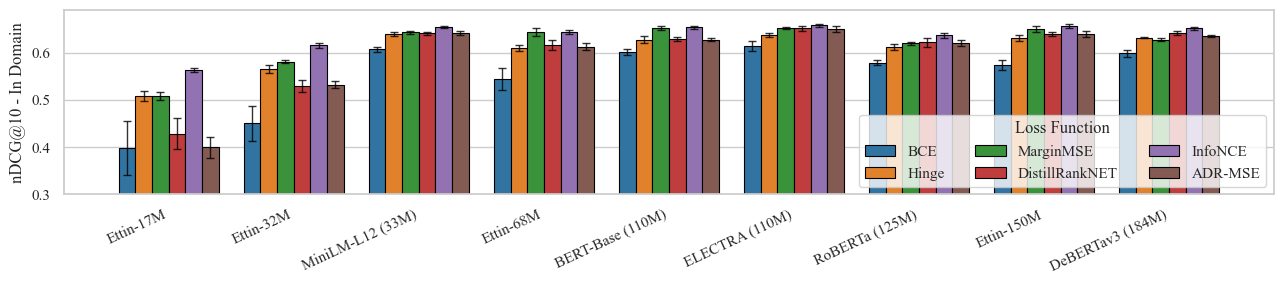

/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_60360/3512770339.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_backbones, rotation=25, ha="right")


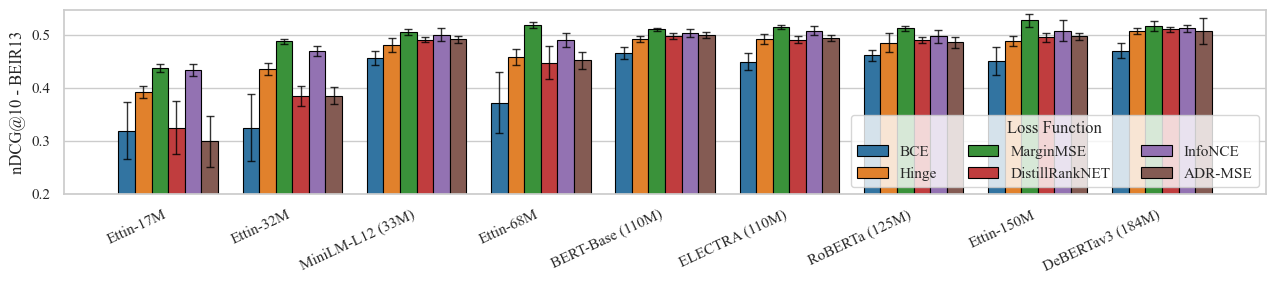

/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_60360/3512770339.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_backbones, rotation=25, ha="right")


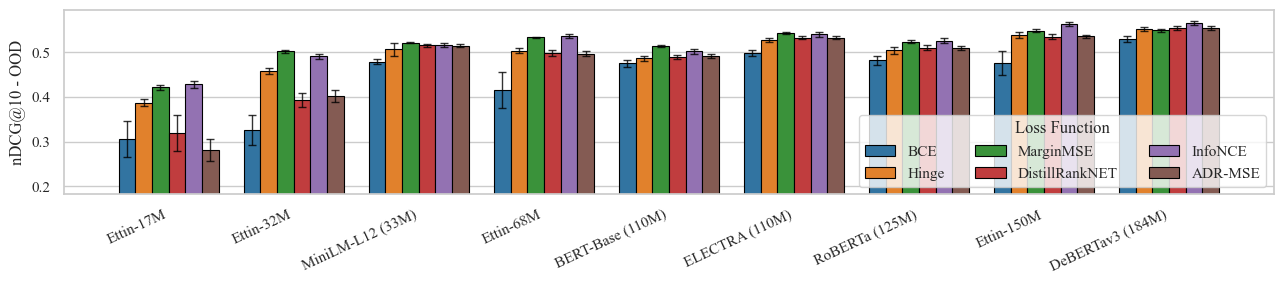

In [48]:
## Mapping and order
agg_to_plot = [
    "In Domain",
    "BEIR13",
    "OOD",
]
loss_order = list(loss_names.keys())  # Internal keys for data filtering
backbone_order = list(backbone_names.keys())
clean_labels = list(loss_names.values())  # Pretty names for the legend
figsize = (13,3)

def Histogram_backbonesXLosses(final_summary_df, dataset_to_plot):
    ## 2. Filter and Prepare Data
    df_plot = final_summary_df[final_summary_df["dataset"] == dataset_to_plot].copy()
    df_plot = df_plot[
        (df_plot["loss"].isin(loss_order)) & (df_plot["base"].isin(backbone_order))
    ]
    # Sorting is now based on 'base' then your custom 'loss' order
    df_plot["loss"] = pd.Categorical(
        df_plot["loss"], categories=loss_order, ordered=True
    )
    df_plot["base"] = pd.Categorical(
        df_plot["base"], categories=backbone_order, ordered=True
    )
    df_plot = df_plot.sort_values(["base", "loss"])
    df_plot["nDCG@10_std"] = np.sqrt(df_plot[var_key])
    # display(df_plot)

    ## 3. Visualization
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(style="whitegrid", font="serif")
    # 4. Visualization

    barplot = sns.barplot(
        data=df_plot,
        x="base",
        y=metric_key,
        hue="loss",
        hue_order=loss_order,
        palette="tab10",  # Grayscale is safer for publication
        edgecolor="black",
        linewidth=0.8,
        ax=ax,
    )

    # 5. Add Hatching (Patterns) for better visibility in print
    # hatches = ['///', '...', 'xxx', '---', '\\\\', 'OO']
    # for i, this_bar_group in enumerate(ax.containers):
    #     for bar in this_bar_group:
    #         bar.set_hatch(hatches[i % len(hatches)])

    # 6. Error Barsbackbone_idx_map = {name: i for i, name in enumerate(backbone_order)}
    for i, loss_key in enumerate(loss_order):
        bar_group = ax.containers[i]
        subset = df_plot[df_plot["loss"] == loss_key].set_index("base")
        
        x_coords, y_errs, y_vals = [], [], []
        
        for bar, b_name in zip(bar_group, backbone_order):
            if b_name in subset.index:
                # Get the value
                val = subset.loc[b_name, metric_key]
                err = subset.loc[b_name, "nDCG@10_std"]
                
                # --- THE FIX ---
                # If these are Series (duplicates found), take the first one or mean
                # Using .mean() is safer if you have multiple seeds per backbone
                final_y = val.mean() if isinstance(val, pd.Series) else val
                final_err = err.mean() if isinstance(err, pd.Series) else err
                
                x_coords.append(bar.get_x() + bar.get_width() / 2)
                y_vals.append(final_y)
                y_errs.append(final_err)

        if x_coords:
            ax.errorbar(
                x=x_coords,
                y=y_vals,
                yerr=y_errs,
                fmt="none",
                c="black",
                capsize=3,
                elinewidth=1,
                alpha=0.8,
            )

    # 7. Labels & Legend
    clean_backbones = [backbone_names[b] for b in backbone_order]
    ax.set_xticklabels(clean_backbones, rotation=25, ha="right")

    handles, _ = ax.get_legend_handles_labels()
    ax.legend(
        handles,
        list(loss_names.values()),
        title="Loss Function",
        loc="lower right",
        ncol=3,
        # bbox_to_anchor=(1.02, 1),
        frameon=True,
    )
    # Styling
    vmin, vmax = min(subset[metric_key]), max(subset[metric_key])
    ax.set_ylim(vmin - 0.1, vmax + 0.04)
    plt.ylabel(f"nDCG@10 - {dataset_to_plot}")
    ax.set_xlabel(None)
    plt.tight_layout()
    plt.savefig(
        f"./local/figures/BackbonesXLosses_{dataset_to_plot.replace(' ', '_')}.pdf"
    )

    plt.show()


for dataset_to_plot in agg_to_plot:
    assert dataset_to_plot in aggregations_paper.keys()
    Histogram_backbonesXLosses(final_df, dataset_to_plot)

# Tables 

## Comparison with RankDistiLLM
we extract the results from the main dataframe, but we are evaluating with the top $1000$ from `splade-v3-distillbert`, whereas they are using the top 100 from ColBERTv2

In [ ]:
reproductions = df[
    (df["base"] == "google/electra-base-discriminator")
    & (df["loss"].isin(["distillRankNET", "infoNCE_RankDistiLLM_norm_size=True"]))
    & (df["dataset"].isin(["trec2020", "trec2019"]))
].copy()

reproductions["nDCG@10_std"] = np.sqrt(100 * reproductions["nDCG@10_var"])
reproductions["nDCG@10_mean"] = 100 * reproductions["nDCG@10_mean"]
cols_to_show = ["base", "loss", "dataset", "nDCG@10_mean", "nDCG@10_std"]

# Filter for existing columns only to prevent errors
existing_cols = [c for c in cols_to_show if c in reproductions.columns]

display(reproductions[existing_cols])

,base,loss,dataset,nDCG@10_mean,nDCG@10_std
586,google/electra-base-discriminator,distillRankNET,trec2019,76.99334,0.081070
588,google/electra-base-discriminator,infoNCE_RankDistiLLM_norm_size=True,trec2019,75.18000,0.026851
616,google/electra-base-discriminator,distillRankNET,trec2020,74.40000,0.040583
618,google/electra-base-discriminator,infoNCE_RankDistiLLM_norm_size=True,trec2020,74.50333,0.048274


## Detailed views

In [ ]:
import pandas as pd
# 1. Define the mapping for your columns to match the ID/OOD groups in the image

aggregations_table = {
    "msmarco_dev": ["msmarco_dev"],
    "trec2019": ["trec2019"],
    "trec2020": ["trec2020"],
    "BEIR13 (Semi OOD)": aggregations_paper["BEIR13"],
    "Lotte-S": aggregations_paper["Lotte-S"],
    "robust04": ["robust04"],
}
loss_names_table = {
    "bce": "BCE",
    "hingeLoss": "Hinge",
    "infoNCE_RankDistiLLM_norm_size=True": "InfoNCE (ColBERTv2)",
    "marginMSE": "MarginMSE (\citet{hofstatterImprovingEfficientNeural2020})",
    "distillRankNET": "DistillRankNET (RankDistiLLM \cite{schlattRankDistiLLMClosingEffectiveness2025})",
    "ADR_MSE": "ADR-MSE (RankDistiLLM \cite{schlattRankDistiLLMClosingEffectiveness2025})",
}
all_relevant_datasets = aggregations_table.keys()

<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_8558/1853509003.py:16: SyntaxWarning: invalid escape sequence '\c'
  "marginMSE": "MarginMSE (\citet{hofstatterImprovingEfficientNeural2020})",
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_8558/1853509003.py:17: SyntaxWarning: invalid escape sequence '\c'
  "distillRankNET": "DistillRankNET (RankDistiLLM \cite{schlattRankDistiLLMClosingEffectiveness2025})",
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_8558/1853509003.py:18: SyntaxWarning: invalid escape sequence '\c'
  "ADR_MSE": "ADR-MSE (RankDistiLLM \cite{schlattRankDistiLLMClosingEffectiveness2025})",


In [ ]:
import pandas as pd
import numpy as np

df_latex = final_df.copy()

#Compute aggregations
for name, datasets in aggregations_table.items():
    if len(datasets):
        agg_df = get_aggregated_df(df_latex, datasets=datasets, name=name)
        df_latex = pd.concat([df_latex, agg_df])

# filter 
df_latex = df_latex[
    (df_latex["dataset"].isin(all_relevant_datasets))
    & ~(df_latex["loss"].isin(ignore_losses))
]
#reorder 
ordered_loss_keys = list(loss_names_table.keys())
df_latex['loss'] = pd.Categorical(
    df_latex['loss'], 
    categories=ordered_loss_keys, 
    ordered=True
)

df_latex["loss"] = df_latex["loss"].apply(lambda x: loss_names_table[x])
df_latex["dataset"] = df_latex["dataset"].apply(lambda x: DATASET_TO_ABB.get(x, x))


def format_latex_backbone(x):
    name = backbone_names.get(x, x)  # Fallback to x if key not found
    return rf"\textbf{{{name}}}"

pivot_df = df_latex.pivot_table(
    index=["base", "loss"], columns="dataset", values="nDCG@10_mean"
)
# Reindexing and renaming logic as per your snippet
pivot_df = pivot_df.reindex(index=backbone_names.keys(), level=0)
pivot_df.index = pivot_df.index.set_levels(
    [format_latex_backbone(x) for x in pivot_df.index.levels[0]], level=0
)
pivot_df = pivot_df[[DATASET_TO_ABB.get(x, x) for x in all_relevant_datasets]]

# --- New Shading and Formatting Logic ---

def format_colored_cells(col):
    """
    Applies blue/red shading based on median and bolds the column maximum.
    """
    # 1. Calculations for shading
    lo = col.min()
    hi = col.max()
    mid = col.median()
    max_shade = 20  # Max intensity for LaTeX (e.g., red!20)
    
    formatted_cells = []
    
    for val in col:
        # Determine Color Shade
        color_cmd = ""
        if hi != lo:
            if val <= mid:
                # Blue for below median
                t = (mid - val) / (mid - lo) if mid > lo else 0
                shade = int(round(t * max_shade))
                if shade > 0: color_cmd = f"\\cellcolor{{blue!{shade}}}"
            else:
                # Red for above median
                t = (val - mid) / (hi - mid) if hi > mid else 0
                shade = int(round(t * max_shade))
                if shade > 0: color_cmd = f"\\cellcolor{{red!{shade}}}"

        # Determine Text Style (Bold for column max)
        val_str = f"{val:.3f}"
        if val == hi:
            val_str = f"\\textbf{{{val_str}}}"
            
        formatted_cells.append(f"{color_cmd}{val_str}")
        
    return formatted_cells

display(pivot_df)

# Apply the coloring/bolding function
styled_df = pivot_df.apply(format_colored_cells)

# --- Generate LaTeX ---

# We use styled_df for to_latex, but escape=False is crucial 
# so LaTeX commands aren't escaped to \textbackslash
latex_output = styled_df.to_latex(
    multicolumn=True,
    multirow=True,
    caption="Evaluation Results. Shading: \\colorbox{red!15}{red} above median, \\colorbox{blue!15}{blue} below.",
    label="tab:results",
    column_format="ll" + "c" * len(pivot_df.columns),
    escape=False  # Required to keep \cellcolor and \textbf
)

# Fix multirow alignment as in your original script
final_latex = latex_output.replace(
        "\multirow[t]", "\multirow[c]"
    ).replace(
        "\cline{1-8}", "\midrule"
    )

with open("./local/figures/evaluation_table.tex", "w") as f:
    f.write(final_latex)

print("File 'evaluation_table.tex' with shading has been created.")

<>:101: SyntaxWarning: invalid escape sequence '\m'
<>:101: SyntaxWarning: invalid escape sequence '\m'
<>:103: SyntaxWarning: invalid escape sequence '\c'
<>:103: SyntaxWarning: invalid escape sequence '\m'
<>:101: SyntaxWarning: invalid escape sequence '\m'
<>:101: SyntaxWarning: invalid escape sequence '\m'
<>:103: SyntaxWarning: invalid escape sequence '\c'
<>:103: SyntaxWarning: invalid escape sequence '\m'
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_8558/2474603248.py:101: SyntaxWarning: invalid escape sequence '\m'
  "\multirow[t]", "\multirow[c]"
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_8558/2474603248.py:101: SyntaxWarning: invalid escape sequence '\m'
  "\multirow[t]", "\multirow[c]"
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_8558/2474603248.py:103: SyntaxWarning: invalid escape sequence '\c'
  "\cline{1-8}", "\midrule"
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_8558/2474603248.py:103: SyntaxWarning: invalid esc

KeyError: nan

# Figure 2

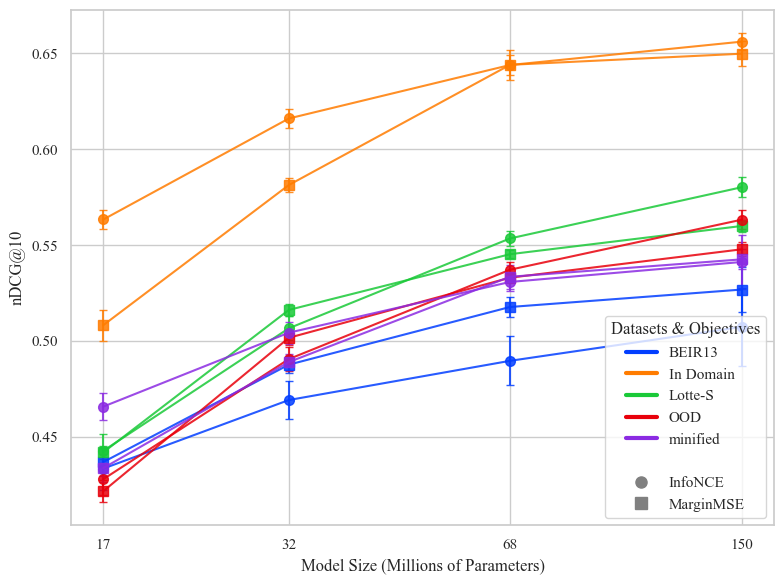

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path


def plot_ettin_scaling_refined(
    df, selected_losses=None, selected_datasets=None, loss_names=None
):
    # Ensure mapping dict exists
    loss_names = loss_names or {}

    # 1. Filter and Prepare Data
    plot_df = df[df["base"].str.contains("ettin", na=False)].copy()
    plot_df["model_size"] = plot_df["base"].str.extract(r"-(\d+)m").astype(int)
    plot_df["nDCG@10_std"] = np.sqrt(plot_df["nDCG@10_var"])

    # Apply user selections
    if selected_losses:
        plot_df = plot_df[plot_df["loss"].isin(selected_losses)]
    if selected_datasets:
        plot_df = plot_df[plot_df["dataset"].isin(selected_datasets)]

    plot_df = plot_df.sort_values("model_size")

    # 2. Setup Aesthetic Mappings
    sns.set_theme(style="whitegrid", font="serif")
    fig, ax = plt.subplots(figsize=(8, 6))

    # Sticky colors for datasets
    unique_ds = sorted(plot_df["dataset"].unique())
    palette = dict(zip(unique_ds, sns.color_palette("bright", len(unique_ds))))

    # Markers for losses
    unique_ls = sorted(plot_df["loss"].unique())
    markers = ["o", "s", "^", "D", "p", "H", "X"]
    marker_map = dict(zip(unique_ls, markers[: len(unique_ls)]))

    # 3. Plotting with Groupby
    for (ds, ls), subset in plot_df.groupby(["dataset", "loss"]):
        ax.errorbar(
            x=subset["model_size"],
            y=subset["nDCG@10_mean"],
            yerr=subset["nDCG@10_std"],
            color=palette[ds],
            marker=marker_map[ls],
            linestyle="-",
            linewidth=1.5,
            markersize=7,
            capsize=3,
            alpha=0.85,
        )

    # 4. Legend Construction (Using loss_names)
    # Part A: Dataset Colors
    ds_handles = [Line2D([0], [0], color=palette[d], lw=3, label=d) for d in unique_ds]

    # Part B: Loss Markers (Prettified)
    ls_handles = [
        Line2D(
            [0],
            [0],
            marker=marker_map[l],
            color="gray",
            ls="",
            markersize=8,
            label=loss_names.get(l, l),
        )
        for l in unique_ls
    ]

    # Combine with a spacer
    spacer = Line2D([0], [0], color="none", label="")
    ax.legend(
        handles=ds_handles + [spacer] + ls_handles,
        # bbox_to_anchor=(1.02, 1),
        loc="lower right",
        title="Datasets & Objectives",
        frameon=True,
    )

    # 5. Final Polish
    ax.set(
        xscale="log",
        xlabel="Model Size (Millions of Parameters)",
        ylabel="nDCG@10",
    )

    # Format X-axis to show actual size numbers
    ticks = sorted(plot_df["model_size"].unique())
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    plt.savefig("./local/figures/scaling_law_ettin.pdf")
    plt.show()


# Select what you want to see
plot_ettin_scaling_refined(
    final_summary_df,
    selected_losses=[
        "marginMSE",
        #  "distillRankNET",
        "infoNCE_RankDistiLLM_norm_size=True",
    ],
    selected_datasets=aggregations_paper.keys(),
    loss_names=loss_names,
)

# Figure 3

## Loading Data

In [ ]:
# Main table

xps = [
    "colbertNeg_mini",
    "colbertNeg_base",
]

def process_results_v2(results) -> pd.DataFrame:
    labels1 = results.columns
    labels2 = results.iloc[0]
    labels = [
        f"{l1.split('.')[0]}{'_' + str(l2) if str(l2) != 'nan' else ''}"
        for l1, l2 in zip(labels1, labels2)
    ]
    labels[0] = "dataset"
    results.columns = labels
    results = results.iloc[2:]
    # Select columns containing 'mean' or 'var' (case-insensitive)
    cols_to_convert = results.filter(regex="(?i)mean|var").columns
    # Convert those columns to numeric, turning errors (like 'None' strings) into NaN
    results[cols_to_convert] = results[cols_to_convert].apply(
        pd.to_numeric, errors="coerce"
    )

    return results

raw_dfs = []
for xp in xps:
    xp_path = get_last_xp(xps_root / xp)
    xp_path = xps_root / xp / "20260418_142408"
    xp_path = xps_root / xp / "dry-run"
    print(f"Using xp path: {xp_path}")
    # raw_dfs.append(get_results(xp_path))
    raw_dfs.append(process_results_v2(get_results(xp_path)))

v2_df = pd.concat(raw_dfs)
# Create a list to store the new summary dataframes


summary_dfs = [v2_df]

for name, datasets in aggregations_paper.items():
    agg_result = get_aggregated_df(v2_df, datasets=datasets, name=name)
    summary_dfs.append(agg_result)


datasets = list(v2_df["dataset"].unique())
display(v2_df.head())
print(f"{len(datasets)} unique datasets : {datasets}")
print(f" - Losses : {list(v2_df['loss'].unique())}")
print(f" - Backbones : {list(v2_df['base'].unique())}")

# Combine all aggregations into one single new table
final_df = pd.concat(summary_dfs, ignore_index=True)
print(f" - unique datasets in Summary: {list(summary_df_v2['dataset'].unique())}")

Found dates for /Users/victor/code/experiments/JZ/colbertNeg_mini: ['20260430_115713', '20260504_183035', '20260505_105350', '20260506_191814', 'current', 'dry-run']
Most recent date for /Users/victor/code/experiments/JZ/colbertNeg_mini: 20260506_191814
Using xp path: /Users/victor/code/experiments/JZ/colbertNeg_mini/dry-run
Found dates for /Users/victor/code/experiments/JZ/colbertNeg_base: ['20260429_162228', '20260430_114806', '20260430_114830', '20260505_105512', '20260505_110352', '20260506_191814', 'current', 'dry-run', 'lock']
Most recent date for /Users/victor/code/experiments/JZ/colbertNeg_base: 20260506_191814
Using xp path: /Users/victor/code/experiments/JZ/colbertNeg_base/dry-run


,dataset,base,first_stage,loss,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
2,BEIR13,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,bce_RankDistiLLM,0.490541,0.002210,0.614820,0.003050,0.407023,0.001178,0.418641,0.001109
3,BEIR13,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,hingeLoss_RankDistiLLM,0.518703,0.000139,0.630646,0.000134,0.429451,0.000051,0.437859,0.000042
4,BEIR13,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,infoNCE_RankDistiLLM,0.515392,0.000716,0.628690,0.000550,0.429759,0.000379,0.438936,0.000314
5,In Domain,NaN,naver/splade-v3-distilbert,NaN,0.777467,NaN,0.849500,NaN,0.648667,NaN,0.641100,NaN
6,In Domain,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,bce_RankDistiLLM,0.761544,0.000045,0.837422,0.000015,0.622578,0.000036,0.616333,0.000003


27 unique datasets : ['BEIR13', 'In Domain', 'Lotte-S', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'lotte_lifestyle', 'lotte_recreation', 'lotte_science', 'lotte_technology', 'lotte_writing', 'mean', 'minified', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'robust04', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid']
 - Losses : ['bce_RankDistiLLM', 'hingeLoss_RankDistiLLM', 'infoNCE_RankDistiLLM', nan]
 - Backbones : ['microsoft/MiniLM-L12-H384-uncased', nan, 'jhu-clsp/ettin-encoder-150m', 'microsoft/deberta-v3-base']
 - unique datasets in Summary: ['BEIR13', 'In Domain', 'Lotte-S', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'lotte_lifestyle', 'lotte_recreation', 'lotte_science', 'lotte_technology', 'lotte_writing', 'mean', 'minified', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'robust04', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid', 'OOD']


In [ ]:
metric_key = "nDCG@10_mean"
var_key = "nDCG@10_var"

cols_to_keep = [
    metric_key,
    var_key,
    "loss",
    "base",
    "dataset",
    "first_stage"
]

replace_names = {
    "Mean In Domain": "In Domain",
    "BEIR 13": "BEIR13",
}

for col_name in ["dataset", "loss"]:
    final_df = final_df[final_df[col_name].notna()]
    final_df[col_name] = final_df[col_name].apply(lambda x: replace_names.get(x,x))

display(final_df)
datasets = list(final_df['dataset'].unique())
backbones = list(final_df['base'].unique())
print(f"{len(datasets)} unique datasets : {datasets}")
print(f"unique losses : {list(final_df['loss'].unique())}")
print(f"Backbones : {backbones}")

,dataset,base,first_stage,loss,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
0,BEIR13,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,bce_RankDistiLLM,0.490541,0.002210,0.614820,3.049584e-03,0.407023,0.001178,0.418641,0.001109
1,BEIR13,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,hingeLoss_RankDistiLLM,0.518703,0.000139,0.630646,1.337075e-04,0.429451,0.000051,0.437859,0.000042
2,BEIR13,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,infoNCE_RankDistiLLM,0.515392,0.000716,0.628690,5.497253e-04,0.429759,0.000379,0.438936,0.000314
4,In Domain,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,bce_RankDistiLLM,0.761544,0.000045,0.837422,1.507691e-05,0.622578,0.000036,0.616333,0.000003
5,In Domain,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,hingeLoss_RankDistiLLM,0.773000,0.000055,0.846133,8.811836e-07,0.644956,0.000003,0.639067,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...
329,OOD,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,hingeLoss_RankDistiLLM,0.558617,0.000618,0.694078,9.748149e-04,0.449706,0.000415,0.466061,0.000323
330,OOD,microsoft/MiniLM-L12-H384-uncased,naver/splade-v3-distilbert,infoNCE_RankDistiLLM,0.533767,0.002485,0.670683,3.046909e-03,0.433328,0.000882,0.451483,0.000721
331,OOD,microsoft/deberta-v3-base,naver/splade-v3-distilbert,bce_RankDistiLLM,0.638789,0.000282,0.783533,2.090441e-04,0.539106,0.000127,0.554033,0.000094
332,OOD,microsoft/deberta-v3-base,naver/splade-v3-distilbert,hingeLoss_RankDistiLLM,0.668833,0.000121,0.803928,5.800266e-05,0.558883,0.000098,0.573011,0.000089


28 unique datasets : ['BEIR13', 'In Domain', 'Lotte-S', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'lotte_lifestyle', 'lotte_recreation', 'lotte_science', 'lotte_technology', 'lotte_writing', 'mean', 'minified', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'robust04', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid', 'OOD']
unique losses : ['bce_RankDistiLLM', 'hingeLoss_RankDistiLLM', 'infoNCE_RankDistiLLM']
Backbones : ['microsoft/MiniLM-L12-H384-uncased', 'jhu-clsp/ettin-encoder-150m', 'microsoft/deberta-v3-base']


## Plotting

/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_60360/1960469922.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_backbones, rotation=25, ha="right")


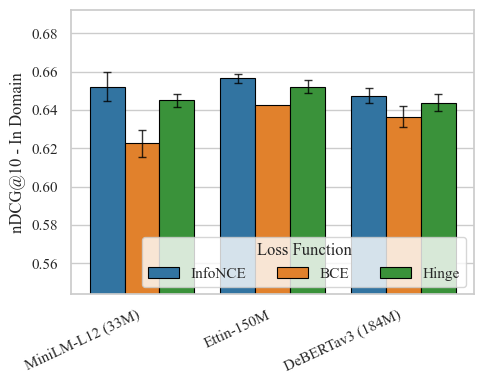

/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_60360/1960469922.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_backbones, rotation=25, ha="right")


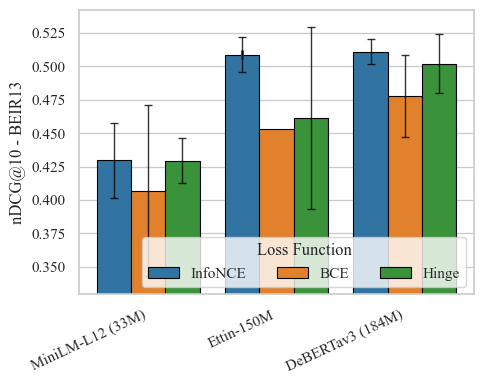

/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_60360/1960469922.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clean_backbones, rotation=25, ha="right")


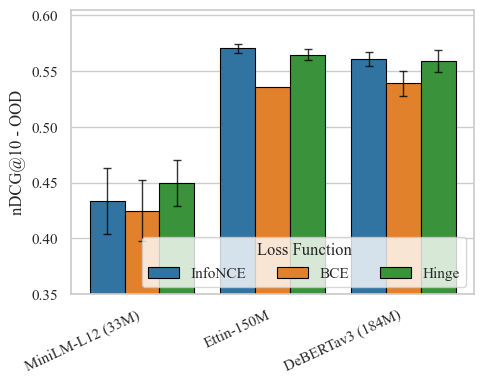

In [ ]:
figsize = (5, 4)

## Mapping and order
agg_to_plot = [
    "In Domain",
    "BEIR13",
    "OOD",
]

loss_names_fig2 = {
    "infoNCE_RankDistiLLM": "InfoNCE",
    "bce_RankDistiLLM": "BCE",
    "hingeLoss_RankDistiLLM": "Hinge",
}

backbone_names_fig2 = {k:v for k,v in backbone_names.items() if k in backbones}
loss_order = list(loss_names_fig2.keys())  # Internal keys for data filtering
backbone_order = list(backbone_names_fig2.keys())
clean_labels = list(loss_names_fig2.values())  # Pretty names for the legend

def Histogram_backbonesXLosses(final_summary_df, dataset_to_plot):
    ## 2. Filter and Prepare Data
    df_plot = final_summary_df[final_summary_df["dataset"] == dataset_to_plot].copy()
    df_plot = df_plot[
        (df_plot["loss"].isin(loss_order)) & (df_plot["base"].isin(backbone_order))
    ]
    # Sorting is now based on 'base' then your custom 'loss' order
    df_plot["loss"] = pd.Categorical(
        df_plot["loss"], categories=loss_order, ordered=True
    )
    df_plot["base"] = pd.Categorical(
        df_plot["base"], categories=backbone_order, ordered=True
    )
    df_plot = df_plot.sort_values(["base", "loss"])
    df_plot["nDCG@10_std"] = np.sqrt(df_plot[var_key])
    # display(df_plot)

    ## 3. Visualization
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(style="whitegrid", font="serif")
    # 4. Visualization

    barplot = sns.barplot(
        data=df_plot,
        x="base",
        y=metric_key,
        hue="loss",
        hue_order=loss_order,
        palette="tab10",  # Grayscale is safer for publication
        edgecolor="black",
        linewidth=0.8,
        ax=ax,
    )

    # 5. Add Hatching (Patterns) for better visibility in print
    # hatches = ['///', '...', 'xxx', '---', '\\\\', 'OO']
    # for i, this_bar_group in enumerate(ax.containers):
    #     for bar in this_bar_group:
    #         bar.set_hatch(hatches[i % len(hatches)])

    # 6. Error Barsbackbone_idx_map = {name: i for i, name in enumerate(backbone_order)}
    for i, loss_key in enumerate(loss_order):
        bar_group = ax.containers[i]
        subset = df_plot[df_plot["loss"] == loss_key].set_index("base")
        
        x_coords, y_errs, y_vals = [], [], []
        
        for bar, b_name in zip(bar_group, backbone_order):
            if b_name in subset.index:
                # Get the value
                val = subset.loc[b_name, metric_key]
                err = subset.loc[b_name, "nDCG@10_std"]
                
                # --- THE FIX ---
                # If these are Series (duplicates found), take the first one or mean
                # Using .mean() is safer if you have multiple seeds per backbone
                final_y = val.mean() if isinstance(val, pd.Series) else val
                final_err = err.mean() if isinstance(err, pd.Series) else err
                
                x_coords.append(bar.get_x() + bar.get_width() / 2)
                y_vals.append(final_y)
                y_errs.append(final_err)

        if x_coords:
            ax.errorbar(
                x=x_coords,
                y=y_vals,
                yerr=y_errs,
                fmt="none",
                c="black",
                capsize=3,
                elinewidth=1,
                alpha=0.8,
            )

    # 7. Labels & Legend
    clean_backbones = [backbone_names_fig2[b] for b in backbone_order]
    ax.set_xticklabels(clean_backbones, rotation=25, ha="right")

    handles, _ = ax.get_legend_handles_labels()
    ax.legend(
        handles,
        list(loss_names_fig2.values()),
        title="Loss Function",
        loc="lower right",
        ncol=3,
        # bbox_to_anchor=(1.02, 1),
        frameon=True,
    )
    # Styling
    vmin, vmax = min(subset[metric_key]), max(subset[metric_key])
    ax.set_ylim(vmin - 0.1, vmax + 0.04)
    plt.ylabel(f"nDCG@10 - {dataset_to_plot}")
    ax.set_xlabel(None)
    plt.tight_layout()
    plt.savefig(
        f"./local/figures/BackbonesXLossesColbertNeg_{dataset_to_plot.replace(' ', '_')}.pdf"
    )

    plt.show()


for dataset_to_plot in agg_to_plot:
    assert dataset_to_plot in aggregations_paper.keys()
    Histogram_backbonesXLosses(final_df, dataset_to_plot)

# Internal - correlation analysis

In [ ]:
# Main table
import pandas as pd

xps = [
    "eval_scorer_top100",
]

def get_tag(tagspath: str, regex: str) -> dict:
    match = re.search(regex, tagspath)
    if match:
        return match.group(1)
    return None

raw_dfs = []
for xp in xps:
    xp_path = xps_root / xp / "dry-run"
    raw_dfs.append(get_results(xp_path))

df = pd.concat(raw_dfs)

datasets = list(df["dataset"].unique())
print(f"{len(datasets)} unique datasets : {datasets}")
# print(f"Backbones : {list(df['scorer'].unique())}")
df.head()

20 unique datasets : ['msmarco_dev', 'trec2019', 'trec2020', 'fever', 'arguana', 'climate_fever', 'dbpedia', 'fiqa', 'hotpotqa', 'nfcorpus', 'nq', 'quora', 'scidocs', 'scifact', 'touche', 'trec_covid', 'In Domain', 'minified', 'BEIR13', 'mean']


,dataset,first_stage,scorer,scorer_type,RR@10,Success@5,nDCG@10,nDCG@20
0,msmarco_dev,naver/splade-v3-distilbert,NaN,NaN,0.3872,0.5670,0.4524,0.4768
1,msmarco_dev,naver/splade-v3-distilbert,cross-encoder/ms-marco-MiniLM-L12-v2,hf,0.4081,0.5881,0.4731,0.4963
2,msmarco_dev,naver/splade-v3-distilbert,naver/trecdl22-crossencoder-debertav3,hf,0.4053,0.5948,0.4736,0.4982
3,msmarco_dev,naver/splade-v3-distilbert,xpmir/cross-encoder-MiniLM-L12-MarginMSE,hf,0.4021,0.5755,0.4669,0.4917
4,msmarco_dev,naver/splade-v3-distilbert,xpmir/cross-encoder-bert-base-infoNCE,hf,0.4014,0.5791,0.4670,0.4910


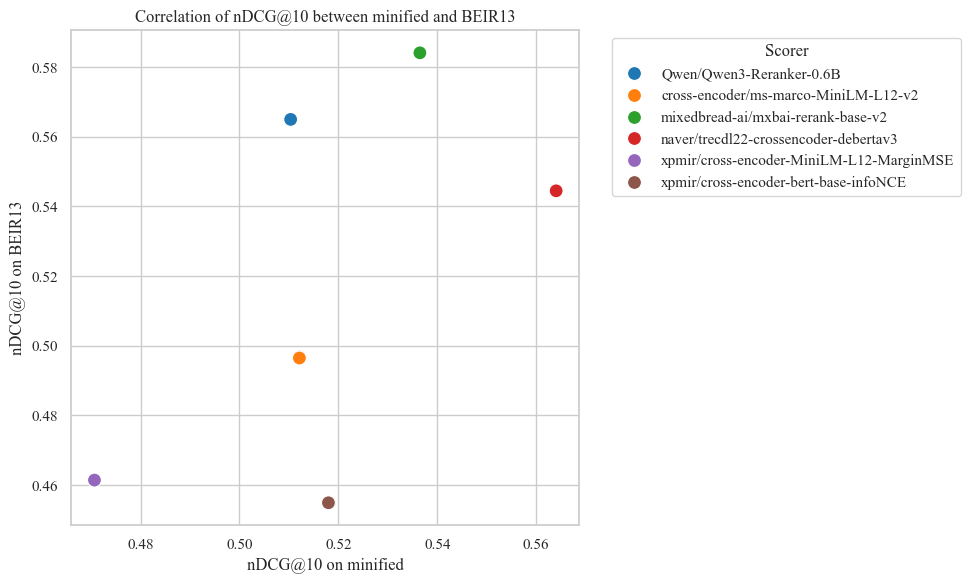

In [ ]:
metric_key = "nDCG@10"
dataset_x = "minified"
dataset_y = "BEIR13"

#plot performance so see correlation between performance on minified and beir13

df_filtered_x = df[df["dataset"] == dataset_x]
df_filtered_y = df[df["dataset"] == dataset_y]
labels = df_filtered_x["scorer"]  # Assuming 'scorer' is the column with model names

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x=df_filtered_x[metric_key].to_numpy(),
    y=df_filtered_y[metric_key].to_numpy(),
    hue=labels,
    palette="tab10",
    s=100,
    ax=ax,
)
ax.set_xlabel(f"{metric_key} on {dataset_x}")
ax.set_ylabel(f"{metric_key} on {dataset_y}")
ax.set_title(f"Correlation of {metric_key} between {dataset_x} and {dataset_y}")
plt.legend(title="Scorer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"./local/figures/correlation_{dataset_x}_{dataset_y}.pdf")
plt.show()